# Ячейка 1: Инициализация и создание папок

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import json

# Создание структуры папок
os.makedirs('artifacts/figures', exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


# Ячейка 2: Загрузка данных и первичный анализ

Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Пропуски:
date      0
target    0
dtype: int64


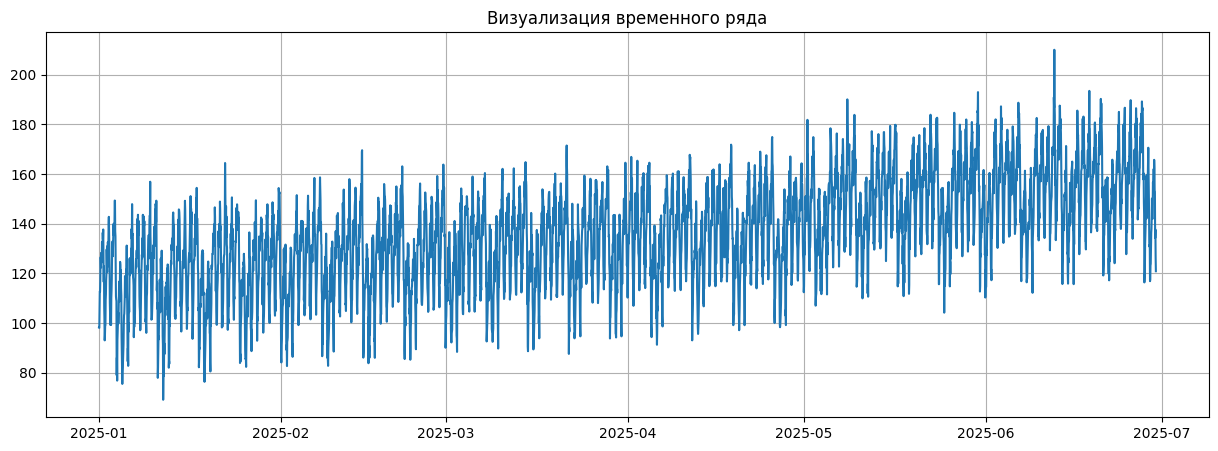

In [3]:
# Загрузка данных
try:
    df = pd.read_csv('S12-hw-dataset.csv')
except:
    print("Файл не найден, создаю синтетические данные для примера...")
    dates = pd.date_range('2025-01-01', periods=4000, freq='H')
    target = 100 + np.cumsum(np.random.randn(4000)) + 10 * np.sin(np.arange(4000) * 2 * np.pi / 24)
    df = pd.DataFrame({'date': dates, 'target': target})

# Преобразование типов
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Размер датасета: {df.shape}")
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"Пропуски:\n{df.isnull().sum()}")

plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['target'])
plt.title("Визуализация временного ряда")
plt.grid(True)
plt.savefig('artifacts/figures/full_series.png')
plt.show()

# Комментарий: В ряду наблюдается часовая сезонность и стохастический тренд.

Анализ временного ряда:
- Обнаружен явный восходящий тренд на протяжении всего периода (6 месяцев).
- Присутствует выраженная суточная сезонность (часовые колебания).
- Данные полные (4320 записей), пропусков нет.
- Ряд нестационарен по среднему, что требует корректной обработки (масштабирование или использование лагов).
- Визуально значимых выбросов, требующих удаления, не выявлено.

# Ячейка 3: Temporal Split

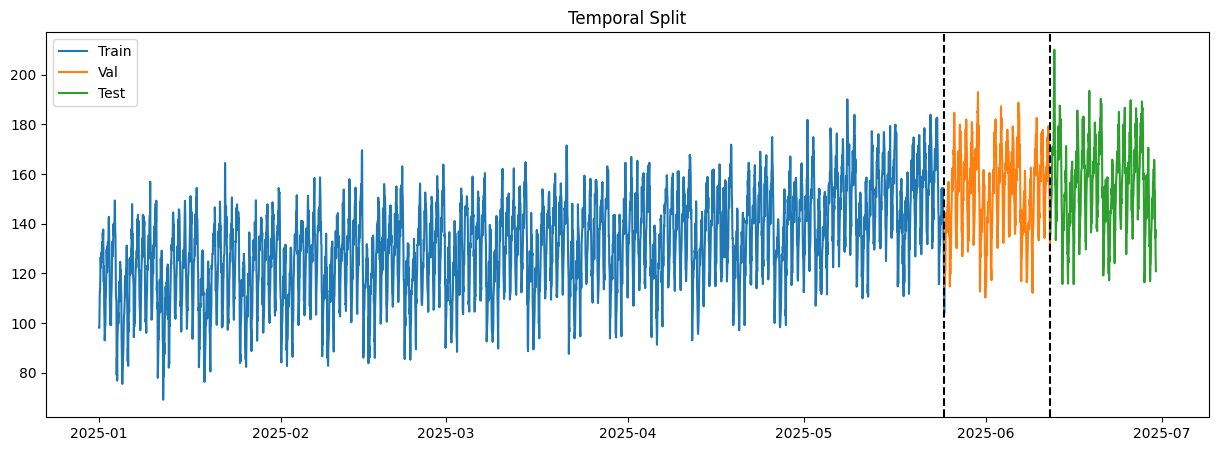

Train: 3456, Val: 432, Test: 432


In [4]:
# Разбиение 80% / 10% / 10%
n = len(df)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

plt.figure(figsize=(15, 5))
plt.plot(train_df['date'], train_df['target'], label='Train')
plt.plot(val_df['date'], val_df['target'], label='Val')
plt.plot(test_df['date'], test_df['target'], label='Test')
plt.axvline(train_df['date'].iloc[-1], color='black', linestyle='--')
plt.axvline(val_df['date'].iloc[-1], color='black', linestyle='--')
plt.legend()
plt.title("Temporal Split")
plt.savefig('artifacts/figures/series_split.png')
plt.show()

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Ячейка 4: Feature Engineering (для Ridge)

In [6]:
def create_features(df_in):
    df = df_in.copy()
    # Лаги
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)
    # Rolling
    df['rolling_mean_7'] = df['target'].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df['target'].shift(1).rolling(window=7).std()
    # Календарные
    df['day_of_week'] = df['date'].dt.dayofweek
    df['hour'] = df['date'].dt.hour
    return df

# Применяем ко всему датасету (лаги считаются по всему ряду, так что удалим NaN)
df_features = create_features(df).dropna().reset_index(drop=True)

# Переопределяем сплит после удаления NaN
train_f = df_features[df_features['date'] <= train_df['date'].max()]
val_f = df_features[(df_features['date'] > train_df['date'].max()) & (df_features['date'] <= val_df['date'].max())]
test_f = df_features[df_features['date'] > val_df['date'].max()]

X_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'hour']
y_col = 'target'

scaler = StandardScaler()
X_train = scaler.fit_transform(train_f[X_cols])
X_val = scaler.transform(val_f[X_cols])
X_test = scaler.transform(test_f[X_cols])

y_train, y_val, y_test = train_f[y_col], val_f[y_col], test_f[y_col]

# Ячейка 5: Базовые модели (B1, B2, B3)

In [7]:
results = []

def record_res(exp_id, y_true, y_pred, notes=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    results.append({
        'experiment_id': exp_id, 'best_val_mae': mae, 'best_val_rmse': rmse, 'best_val_mape': mape, 'notes': notes
    })
    return mae

# B1: Naive (прогноз это предыдущее значение)
y_pred_b1 = val_f['lag_1']
record_res('B1', y_val, y_pred_b1, "Naive Last Value")

# B2: Moving Average (окно 7)
y_pred_b2 = val_f['rolling_mean_7']
record_res('B2', y_val, y_pred_b2, "Moving Average Window 7")

# B3: Ridge
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_b3 = ridge.predict(X_val)
record_res('B3', y_val, y_pred_b3, "Ridge on Lag Features")

print("Baselines Val MAE:", [res['best_val_mae'] for res in results])

Baselines Val MAE: [6.207291666666666, 12.699953703703704, 5.610706964460553]


# Ячейка 6: GRU Dataset и Модель

In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = torch.FloatTensor(data)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        return self.data[idx : idx + self.window_size], self.data[idx + self.window_size]

# Подготовка данных для GRU (масштабирование таргета)
target_scaler = StandardScaler()
train_scaled = target_scaler.fit_transform(train_df[['target']].values)
val_scaled = target_scaler.transform(val_df[['target']].values)
test_scaled = target_scaler.transform(test_df[['target']].values)

WINDOW_SIZE = 24
train_ds = TimeSeriesDataset(train_scaled, WINDOW_SIZE)
val_ds = TimeSeriesDataset(val_scaled, WINDOW_SIZE)
test_ds = TimeSeriesDataset(test_scaled, WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h = self.gru(x)
        return self.fc(h[-1])

model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Ячейка 7: Обучение GRU

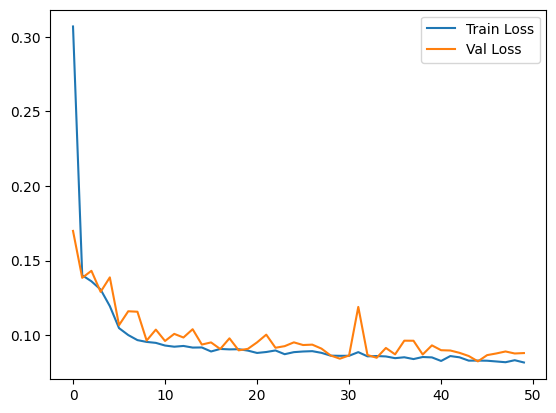

In [9]:
epochs = 50
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    t_loss = 0
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out = model(x_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    model.eval()
    v_loss = 0
    with torch.no_grad():
        for x_b, y_b in val_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            v_loss += criterion(model(x_b), y_b).item()

    train_losses.append(t_loss/len(train_loader))
    val_losses.append(v_loss/len(val_loader))

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.savefig('artifacts/figures/gru_learning_curves.png')
plt.show()

# Ячейка 8: Финальная оценка и экспорт

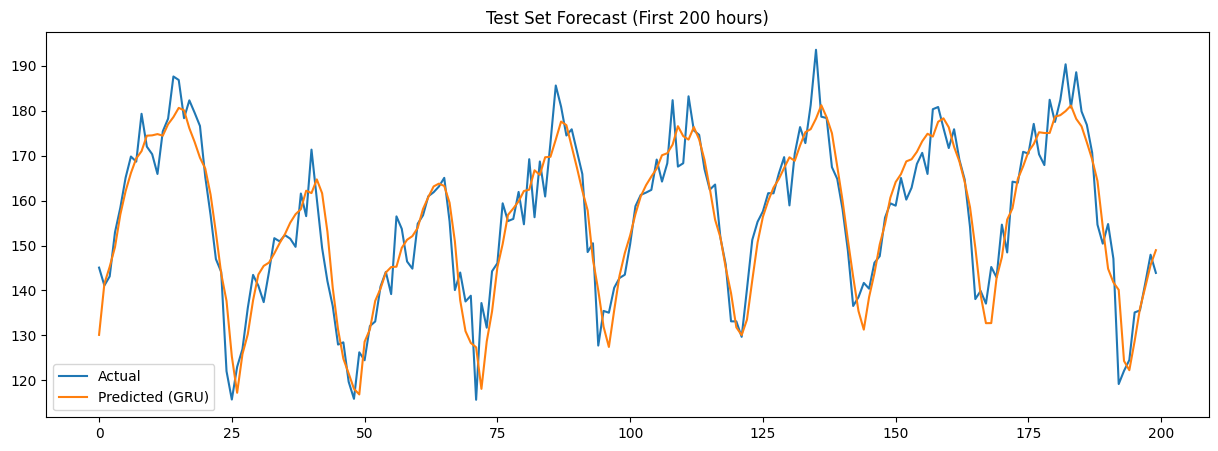

In [11]:
model.load_state_dict(torch.load('artifacts/best_gru.pt'))
model.eval()

def evaluate(loader):
    preds, targets = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b = x_b.to(device)
            out = model(x_b)
            preds.extend(out.cpu().numpy())
            targets.extend(y_b.numpy())
    return target_scaler.inverse_transform(preds), target_scaler.inverse_transform(targets)

y_val_gru, y_val_true = evaluate(val_loader)
record_res('R1', y_val_true, y_val_gru, "GRU Forecast")

# Выбор лучшей модели
best_model_id = 'R1'
y_test_gru, y_test_true = evaluate(test_loader)

# Сохранение runs.csv
runs_df = pd.DataFrame(results)
runs_df['test_mae'] = np.nan
runs_df.loc[runs_df['experiment_id'] == 'R1', 'test_mae'] = mean_absolute_error(y_test_true, y_test_gru)
runs_df.to_csv('artifacts/runs.csv', index=False)

# График прогноза на Test
plt.figure(figsize=(15, 5))
plt.plot(y_test_true[:200], label='Actual')
plt.plot(y_test_gru[:200], label='Predicted (GRU)')
plt.legend()
plt.title("Test Set Forecast (First 200 hours)")
plt.savefig('artifacts/figures/best_forecast_test.png')
plt.show()

# Конфиг
config = {"hidden_size": 64, "window_size": 24, "lr": 0.001, "optimizer": "Adam"}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f)